In [1]:
# Final dependency cell
# ultralytics = YOLO crop support, timm = pretrained ConvNeXt-Tiny backbone
!pip install ultralytics timm -q



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import copy
import time
import math
import random
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from PIL import Image
from ultralytics import YOLO

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from sklearn.model_selection import train_test_split

print("torch:", torch.__version__)


torch: 2.5.1+cu121


## Thesis figure export setup

The following added cells create publication-ready figures and save them automatically inside a local `graphs/` folder.  
The model, training loop, split logic, and evaluation code above/below remain unchanged.


In [3]:
# Added thesis figure utilities
from pathlib import Path
from sklearn.metrics import confusion_matrix

THESIS_GRAPH_DIR = Path.cwd() / "graphs"
THESIS_GRAPH_DIR.mkdir(parents=True, exist_ok=True)

def save_thesis_fig(filename, dpi=300):
    """Save the current matplotlib figure into the thesis graphs folder."""
    path = THESIS_GRAPH_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path

def original_beam_label(class_id):
    """Return original beam label if the remapping dictionary exists."""
    if "id_to_label" in globals():
        return id_to_label.get(int(class_id), int(class_id))
    return int(class_id)

def denormalize_imagenet_tensor(img_tensor):
    """Convert a normalized image tensor back to displayable [0, 1] RGB."""
    mean = torch.tensor([0.485, 0.456, 0.406], dtype=img_tensor.dtype).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], dtype=img_tensor.dtype).view(3, 1, 1)
    img = img_tensor.detach().cpu() * std + mean
    return img.clamp(0, 1)

print("Thesis figures will be saved to:", THESIS_GRAPH_DIR)


Thesis figures will be saved to: e:\Thesis\beam_prediction\graphs


In [4]:
#from google.colab import drive
#drive.mount("/content/drive")

In [5]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.5.1+cu121
12.1
True
NVIDIA GeForce RTX 3050 Laptop GPU


In [6]:
SEED = 88

def set_seed(seed=88):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [7]:
AUTHOR_ROOT = r"E:\Thesis\beam_prediction\Image_beam"
POSITION_ROOT = r"E:\Thesis\beam_prediction\scenario23_paper_style_sequence_split"
EXTRACT_ROOT = r"E:\Thesis\beam_prediction\scenario23_dev_w_resources"

FULL_CSV_PATH = os.path.join(AUTHOR_ROOT, "scenario23_img_beam.csv")

#EXTRACT_ROOT = "/content/scenario23_dev_w_resources"
YOLO_CROP_ROOT = r"E:\Thesis\beam_prediction\yolo_uav_crops_scenario23"

INDEX_COL = "index"
IMAGE_COL = "unit1_rgb"
LABEL_COL = "unit1_beam"

print("AUTHOR_ROOT:", os.path.exists(AUTHOR_ROOT), AUTHOR_ROOT)
print("POSITION_ROOT:", os.path.exists(POSITION_ROOT), POSITION_ROOT)
#print("ZIP_PATH:", os.path.exists(ZIP_PATH), ZIP_PATH)
print("FULL_CSV_PATH:", os.path.exists(FULL_CSV_PATH), FULL_CSV_PATH)

assert os.path.exists(AUTHOR_ROOT)
assert os.path.exists(POSITION_ROOT)
assert os.path.exists(EXTRACT_ROOT)
assert os.path.exists(FULL_CSV_PATH)

AUTHOR_ROOT: True E:\Thesis\beam_prediction\Image_beam
POSITION_ROOT: True E:\Thesis\beam_prediction\scenario23_paper_style_sequence_split
FULL_CSV_PATH: True E:\Thesis\beam_prediction\Image_beam\scenario23_img_beam.csv


In [8]:
X_pos_train = np.load(os.path.join(POSITION_ROOT, "X_train_seq.npy"))
y_train = np.load(os.path.join(POSITION_ROOT, "y_train_seq.npy"))

X_pos_val = np.load(os.path.join(POSITION_ROOT, "X_val_seq.npy"))
y_val = np.load(os.path.join(POSITION_ROOT, "y_val_seq.npy"))

X_pos_test = np.load(os.path.join(POSITION_ROOT, "X_test_seq.npy"))
y_test = np.load(os.path.join(POSITION_ROOT, "y_test_seq.npy"))

print("Position sequences:")
print("train:", X_pos_train.shape, y_train.shape)
print("val  :", X_pos_val.shape, y_val.shape)
print("test :", X_pos_test.shape, y_test.shape)

assert X_pos_train.shape == (7968, 4, 21)
assert X_pos_val.shape == (2276, 4, 21)
assert X_pos_test.shape == (1139, 4, 21)

num_classes = int(max(y_train.max(), y_val.max(), y_test.max()) + 1)
pos_input_dim = X_pos_train.shape[-1]

print("num_classes:", num_classes)
print("pos_input_dim:", pos_input_dim)

Position sequences:
train: (7968, 4, 21) (7968,)
val  : (2276, 4, 21) (2276,)
test : (1139, 4, 21) (1139,)
num_classes: 29
pos_input_dim: 21


In [14]:
full_img_df = pd.read_csv(FULL_CSV_PATH)
full_img_df = full_img_df.sort_values(INDEX_COL).reset_index(drop=True)

print("Full image CSV:", full_img_df.shape)
print("Columns:", full_img_df.columns.tolist())

for col in [INDEX_COL, IMAGE_COL, LABEL_COL]:
    assert col in full_img_df.columns, f"Missing column: {col}"

display(full_img_df.head())
display(full_img_df.tail())

Full image CSV: (11387, 3)
Columns: ['index', 'unit1_rgb', 'unit1_beam']


,index,unit1_rgb,unit1_beam
0,1,../scenario23_dev/unit1/camera_data/image_BS1_...,22
1,2,../scenario23_dev/unit1/camera_data/image_BS1_...,22
2,3,../scenario23_dev/unit1/camera_data/image_BS1_...,22
3,4,../scenario23_dev/unit1/camera_data/image_BS1_...,22
4,5,../scenario23_dev/unit1/camera_data/image_BS1_...,20


,index,unit1_rgb,unit1_beam
11382,11383,../scenario23_dev/unit1/camera_data/image_BS1_...,20
11383,11384,../scenario23_dev/unit1/camera_data/image_BS1_...,19
11384,11385,../scenario23_dev/unit1/camera_data/image_BS1_...,19
11385,11386,../scenario23_dev/unit1/camera_data/image_BS1_...,19
11386,11387,../scenario23_dev/unit1/camera_data/image_BS1_...,19


In [15]:
os.makedirs(EXTRACT_ROOT, exist_ok=True)

marker_file = os.path.join(EXTRACT_ROOT, ".extracted_done")

if not os.path.exists(marker_file):
    print("Extracting scenario23 zip. Wait...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_ROOT)

    with open(marker_file, "w") as f:
        f.write("done")

    print("Extraction completed.")
else:
    print("Already extracted. Skipping.")

print("Extract root sample:")
print(os.listdir(EXTRACT_ROOT)[:30])

Extracting scenario23 zip. Wait...


NameError: name 'ZIP_PATH' is not defined

In [16]:
image_files = []

for root, dirs, files in os.walk(EXTRACT_ROOT):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            image_files.append(os.path.join(root, f))

print("Total extracted image files:", len(image_files))
for p in image_files[:10]:
    print(p)

assert len(image_files) > 0, "No images found after extraction."

image_lookup_basename = {}
image_lookup_suffix = {}

for p in image_files:
    norm_p = p.replace("\\", "/")
    base = os.path.basename(norm_p)
    image_lookup_basename[base] = p

    parts = norm_p.split("/")
    for n in [2, 3, 4, 5, 6, 7, 8]:
        if len(parts) >= n:
            image_lookup_suffix["/".join(parts[-n:])] = p

def resolve_raw_image_path(path_from_csv):
    path_from_csv = str(path_from_csv).replace("\\", "/")
    clean = path_from_csv.lstrip("./").lstrip("/")

    if os.path.exists(path_from_csv):
        return path_from_csv

    candidate = os.path.join(EXTRACT_ROOT, clean)
    if os.path.exists(candidate):
        return candidate

    base = os.path.basename(clean)
    if base in image_lookup_basename:
        return image_lookup_basename[base]

    parts = clean.split("/")
    for n in [8, 7, 6, 5, 4, 3, 2]:
        if len(parts) >= n:
            suffix = "/".join(parts[-n:])
            if suffix in image_lookup_suffix:
                return image_lookup_suffix[suffix]

    return None

full_img_df["raw_image_path"] = full_img_df[IMAGE_COL].apply(resolve_raw_image_path)

missing = full_img_df["raw_image_path"].isna().sum()
print("Missing raw image paths:", missing, "of", len(full_img_df))

assert missing == 0

display(full_img_df[[INDEX_COL, IMAGE_COL, "raw_image_path", LABEL_COL]].head())

Total extracted image files: 11387
E:\Thesis\beam_prediction\scenario23_dev_w_resources\scenario23_dev\unit1\camera_data\image_BS1_10000_17_56_03.jpg
E:\Thesis\beam_prediction\scenario23_dev_w_resources\scenario23_dev\unit1\camera_data\image_BS1_10001_17_56_03.jpg
E:\Thesis\beam_prediction\scenario23_dev_w_resources\scenario23_dev\unit1\camera_data\image_BS1_10002_17_56_03.jpg
E:\Thesis\beam_prediction\scenario23_dev_w_resources\scenario23_dev\unit1\camera_data\image_BS1_10003_17_56_03.jpg
E:\Thesis\beam_prediction\scenario23_dev_w_resources\scenario23_dev\unit1\camera_data\image_BS1_10004_17_56_03.jpg
E:\Thesis\beam_prediction\scenario23_dev_w_resources\scenario23_dev\unit1\camera_data\image_BS1_10005_17_56_03.jpg
E:\Thesis\beam_prediction\scenario23_dev_w_resources\scenario23_dev\unit1\camera_data\image_BS1_10006_17_56_03.jpg
E:\Thesis\beam_prediction\scenario23_dev_w_resources\scenario23_dev\unit1\camera_data\image_BS1_10007_17_56_04.jpg
E:\Thesis\beam_prediction\scenario23_dev_w_re

,index,unit1_rgb,raw_image_path,unit1_beam
0,1,../scenario23_dev/unit1/camera_data/image_BS1_...,E:\Thesis\beam_prediction\scenario23_dev_w_res...,22
1,2,../scenario23_dev/unit1/camera_data/image_BS1_...,E:\Thesis\beam_prediction\scenario23_dev_w_res...,22
2,3,../scenario23_dev/unit1/camera_data/image_BS1_...,E:\Thesis\beam_prediction\scenario23_dev_w_res...,22
3,4,../scenario23_dev/unit1/camera_data/image_BS1_...,E:\Thesis\beam_prediction\scenario23_dev_w_res...,22
4,5,../scenario23_dev/unit1/camera_data/image_BS1_...,E:\Thesis\beam_prediction\scenario23_dev_w_res...,20


Sample raw: E:\Thesis\beam_prediction\scenario23_dev_w_resources\scenario23_dev/unit1/camera_data/image_BS1_1_16_58_42.jpg
Sample crop: E:\Thesis\beam_prediction\yolo_uav_crops_scenario23\image_BS1_1_16_58_42.jpg


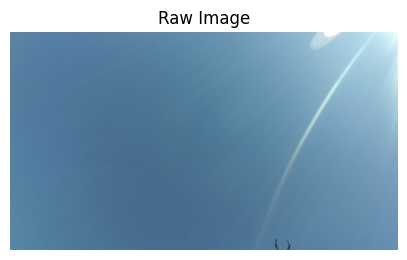

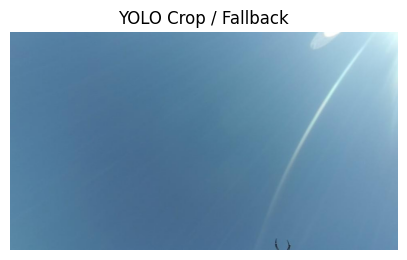

In [17]:
yolo_model = YOLO("yolov8n.pt")

os.makedirs(YOLO_CROP_ROOT, exist_ok=True)

def yolo_crop_image(image_path, save_root=YOLO_CROP_ROOT, conf=0.10, padding=30):
    image_path = str(image_path)

    base = os.path.basename(image_path)
    save_path = os.path.join(save_root, base)

    if os.path.exists(save_path):
        return save_path

    img = Image.open(image_path).convert("RGB")
    w, h = img.size

    results = yolo_model.predict(source=image_path, conf=conf, verbose=False)
    boxes = results[0].boxes

    if boxes is None or len(boxes) == 0:
        img.save(save_path)
        return save_path

    xyxy = boxes.xyxy.cpu().numpy()
    areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
    best_idx = areas.argmax()

    x1, y1, x2, y2 = xyxy[best_idx]

    x1 = max(int(x1) - padding, 0)
    y1 = max(int(y1) - padding, 0)
    x2 = min(int(x2) + padding, w)
    y2 = min(int(y2) + padding, h)

    crop = img.crop((x1, y1, x2, y2))

    if crop.size[0] < 10 or crop.size[1] < 10:
        img.save(save_path)
        return save_path

    crop.save(save_path)
    return save_path

sample_raw = full_img_df["raw_image_path"].iloc[0]
sample_crop = yolo_crop_image(sample_raw)

print("Sample raw:", sample_raw)
print("Sample crop:", sample_crop)

plt.figure(figsize=(5, 5))
plt.imshow(Image.open(sample_raw).convert("RGB"))
plt.axis("off")
plt.title("Raw Image")
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(Image.open(sample_crop).convert("RGB"))
plt.axis("off")
plt.title("YOLO Crop / Fallback")
plt.show()

In [18]:
crop_paths = []

start = time.time()

for i, p in enumerate(full_img_df["raw_image_path"]):
    crop_paths.append(yolo_crop_image(p))

    if (i + 1) % 500 == 0:
        elapsed = (time.time() - start) / 60
        print(i + 1, "/", len(full_img_df), "| elapsed min:", round(elapsed, 2))

full_img_df["image_path"] = crop_paths

print("YOLO crop/fallback completed:", len(crop_paths))

500 / 11387 | elapsed min: 0.32
1000 / 11387 | elapsed min: 0.64
1500 / 11387 | elapsed min: 0.93
2000 / 11387 | elapsed min: 1.19
2500 / 11387 | elapsed min: 1.46
3000 / 11387 | elapsed min: 1.72
3500 / 11387 | elapsed min: 2.0
4000 / 11387 | elapsed min: 2.26
4500 / 11387 | elapsed min: 2.53
5000 / 11387 | elapsed min: 2.8
5500 / 11387 | elapsed min: 3.06
6000 / 11387 | elapsed min: 3.33
6500 / 11387 | elapsed min: 3.59
7000 / 11387 | elapsed min: 3.84
7500 / 11387 | elapsed min: 4.1
8000 / 11387 | elapsed min: 4.36
8500 / 11387 | elapsed min: 4.61
9000 / 11387 | elapsed min: 4.87
9500 / 11387 | elapsed min: 5.14
10000 / 11387 | elapsed min: 5.41
10500 / 11387 | elapsed min: 5.67
11000 / 11387 | elapsed min: 5.94
YOLO crop/fallback completed: 11387


In [19]:
crop_paths = []

start = time.time()

for i, p in enumerate(full_img_df["raw_image_path"]):
    crop_paths.append(yolo_crop_image(p))

    if (i + 1) % 500 == 0:
        elapsed = (time.time() - start) / 60
        print(i + 1, "/", len(full_img_df), "| elapsed min:", round(elapsed, 2))

full_img_df["image_path"] = crop_paths

print("YOLO crop/fallback completed:", len(crop_paths))

500 / 11387 | elapsed min: 0.0
1000 / 11387 | elapsed min: 0.0
1500 / 11387 | elapsed min: 0.0
2000 / 11387 | elapsed min: 0.0
2500 / 11387 | elapsed min: 0.0
3000 / 11387 | elapsed min: 0.0
3500 / 11387 | elapsed min: 0.0
4000 / 11387 | elapsed min: 0.0
4500 / 11387 | elapsed min: 0.0
5000 / 11387 | elapsed min: 0.0
5500 / 11387 | elapsed min: 0.0
6000 / 11387 | elapsed min: 0.0
6500 / 11387 | elapsed min: 0.0
7000 / 11387 | elapsed min: 0.0
7500 / 11387 | elapsed min: 0.0
8000 / 11387 | elapsed min: 0.0
8500 / 11387 | elapsed min: 0.0
9000 / 11387 | elapsed min: 0.0
9500 / 11387 | elapsed min: 0.0
10000 / 11387 | elapsed min: 0.0
10500 / 11387 | elapsed min: 0.0
11000 / 11387 | elapsed min: 0.0
YOLO crop/fallback completed: 11387


In [20]:
def build_image_sequences_from_full_df(df, seq_len=4):
    df = df.sort_values(INDEX_COL).reset_index(drop=True).copy()

    idx_values = df[INDEX_COL].astype(int).values
    img_paths = df["image_path"].astype(str).values

    X_img_seq = []
    target_indices = []

    for i in range(seq_len - 1, len(df) - 1):
        past_idx = idx_values[i - seq_len + 1 : i + 1]
        target_idx = idx_values[i + 1]

        all_idx = np.concatenate([past_idx, [target_idx]])
        expected_idx = np.arange(all_idx[0], all_idx[0] + seq_len + 1)

        if np.array_equal(all_idx, expected_idx):
            X_img_seq.append(img_paths[i - seq_len + 1 : i + 1])
            target_indices.append(target_idx)

    return np.array(X_img_seq, dtype=object), np.array(target_indices, dtype=np.int64)

SEQ_LEN = 4

X_img_all, target_idx_all = build_image_sequences_from_full_df(full_img_df, seq_len=SEQ_LEN)

print("X_img_all:", X_img_all.shape)
print("target_idx_all:", target_idx_all.shape)

total_pos = len(X_pos_train) + len(X_pos_val) + len(X_pos_test)
print("Total position sequences:", total_pos)

assert len(X_img_all) >= total_pos

X_img_all: (11383, 4)
target_idx_all: (11383,)
Total position sequences: 11383


In [21]:
# Build labels from full CSV using same t+1 target index as X_img_all

full_img_df = full_img_df.sort_values(INDEX_COL).reset_index(drop=True)

idx_values = full_img_df[INDEX_COL].astype(int).values
labels_raw = full_img_df[LABEL_COL].astype(int).values

# Remap original beam labels to 0..C-1
all_beam_labels = sorted(full_img_df[LABEL_COL].astype(int).unique())
label_to_id = {label: i for i, label in enumerate(all_beam_labels)}
id_to_label = {i: label for label, i in label_to_id.items()}

y_all = []
target_idx_label = []

SEQ_LEN = 4

for i in range(SEQ_LEN - 1, len(full_img_df) - 1):
    past_idx = idx_values[i - SEQ_LEN + 1 : i + 1]
    target_idx = idx_values[i + 1]

    all_idx = np.concatenate([past_idx, [target_idx]])
    expected_idx = np.arange(all_idx[0], all_idx[0] + SEQ_LEN + 1)

    if np.array_equal(all_idx, expected_idx):
        original_label = int(labels_raw[i + 1])
        y_all.append(label_to_id[original_label])
        target_idx_label.append(target_idx)

y_all = np.array(y_all, dtype=np.int64)
target_idx_label = np.array(target_idx_label, dtype=np.int64)

print("X_img_all:", X_img_all.shape)
print("y_all:", y_all.shape)
print("target_idx_label:", target_idx_label.shape)
print("num_classes:", len(all_beam_labels))

assert len(X_img_all) == len(y_all)

X_img_all: (11383, 4)
y_all: (11383,)
target_idx_label: (11383,)
num_classes: 29


## Thesis figures: dataset and sequence construction

These figures document the input data, target beam distribution, and time-sequence behavior used by the beam tracking model.


Saved figure: e:\Thesis\beam_prediction\graphs\fig_01_raw_vs_yolo_crop.png


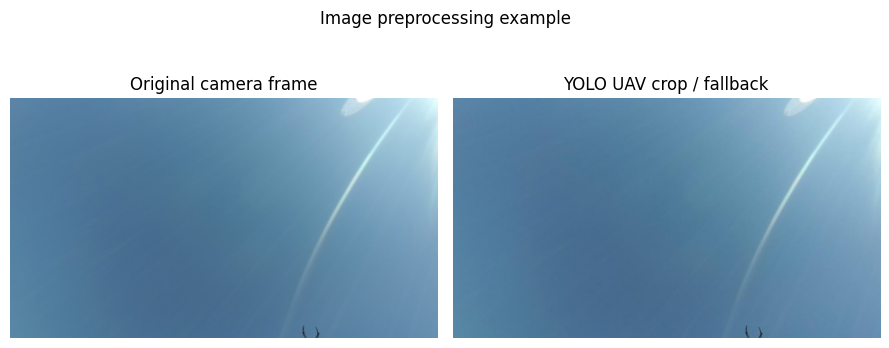

Saved figure: e:\Thesis\beam_prediction\graphs\fig_02_overall_beam_distribution.png


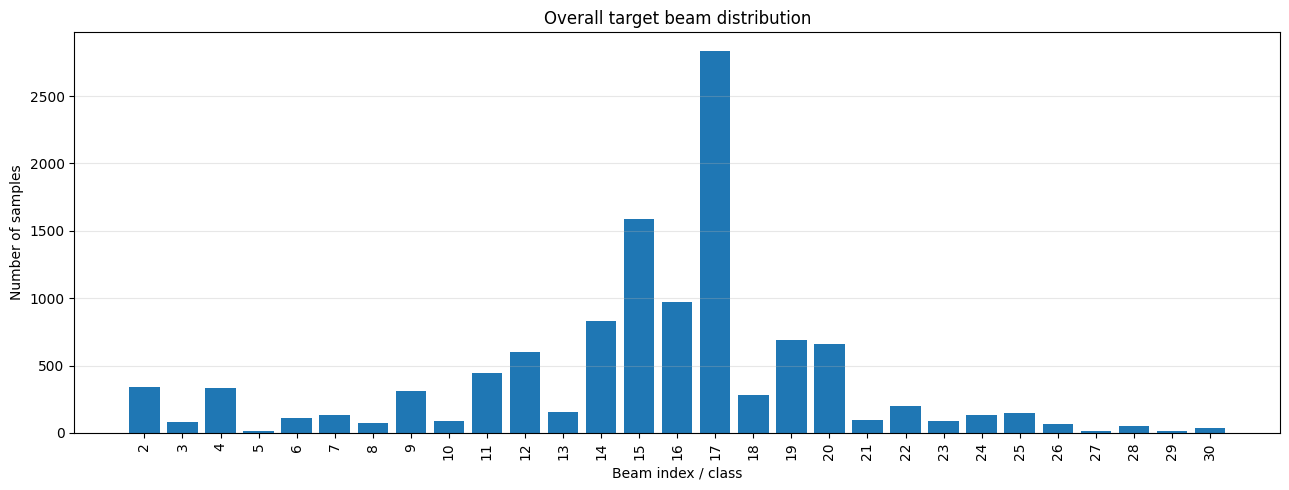

Saved figure: e:\Thesis\beam_prediction\graphs\fig_03_temporal_beam_pattern.png


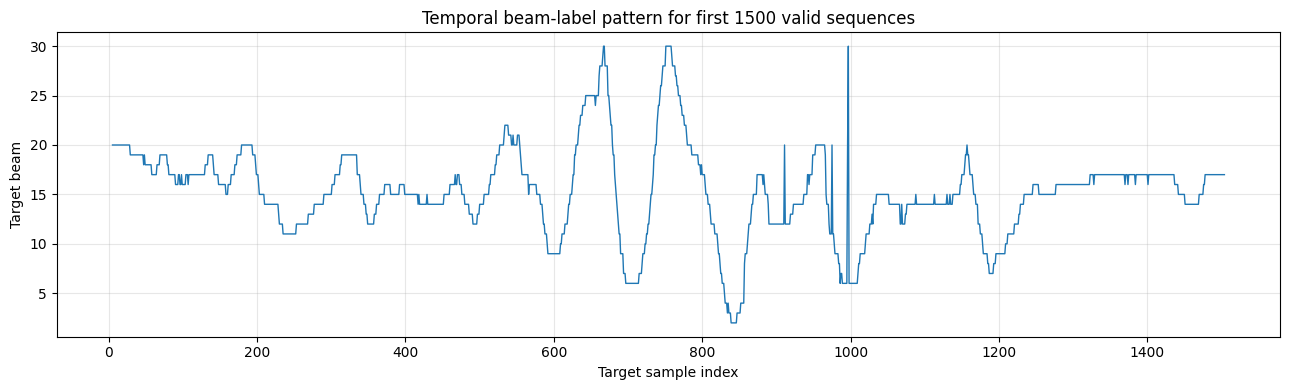

In [22]:
# Figure 1: Raw image vs YOLO-cropped / fallback image
if "full_img_df" in globals() and "raw_image_path" in full_img_df.columns and "image_path" in full_img_df.columns:
    valid_rows = full_img_df[
        full_img_df["raw_image_path"].apply(lambda p: os.path.exists(str(p))) &
        full_img_df["image_path"].apply(lambda p: os.path.exists(str(p)))
    ]
    if len(valid_rows) > 0:
        row = valid_rows.iloc[0]
        raw_img = Image.open(row["raw_image_path"]).convert("RGB")
        crop_img = Image.open(row["image_path"]).convert("RGB")

        fig, axes = plt.subplots(1, 2, figsize=(9, 4))
        axes[0].imshow(raw_img)
        axes[0].set_title("Original camera frame")
        axes[0].axis("off")

        axes[1].imshow(crop_img)
        axes[1].set_title("YOLO UAV crop / fallback")
        axes[1].axis("off")

        fig.suptitle("Image preprocessing example")
        save_thesis_fig("fig_01_raw_vs_yolo_crop.png")
        plt.show()
    else:
        print("Skipped raw-vs-crop figure: no valid image paths were found.")
else:
    print("Skipped raw-vs-crop figure: image path columns are not available yet.")

# Figure 2: Overall beam class distribution
if "y_all" in globals():
    class_ids = np.arange(int(np.max(y_all)) + 1)
    counts = pd.Series(y_all).value_counts().reindex(class_ids, fill_value=0)
    x_labels = [str(original_beam_label(i)) for i in class_ids]

    plt.figure(figsize=(13, 5))
    plt.bar(np.arange(len(class_ids)), counts.values)
    plt.xticks(np.arange(len(class_ids)), x_labels, rotation=90)
    plt.xlabel("Beam index / class")
    plt.ylabel("Number of samples")
    plt.title("Overall target beam distribution")
    plt.grid(axis="y", alpha=0.3)
    save_thesis_fig("fig_02_overall_beam_distribution.png")
    plt.show()
else:
    print("Skipped beam distribution figure: y_all is not available yet.")

# Figure 3: Target beam sequence over chronological sample index
if "target_idx_all" in globals() and "y_all" in globals():
    n_plot = min(1500, len(y_all))
    plt.figure(figsize=(13, 4))
    plt.plot(target_idx_all[:n_plot], [original_beam_label(v) for v in y_all[:n_plot]], linewidth=1)
    plt.xlabel("Target sample index")
    plt.ylabel("Target beam")
    plt.title(f"Temporal beam-label pattern for first {n_plot} valid sequences")
    plt.grid(True, alpha=0.3)
    save_thesis_fig("fig_03_temporal_beam_pattern.png")
    plt.show()
else:
    print("Skipped temporal beam-pattern figure: target_idx_all/y_all is not available yet.")


In [23]:
# Recombine position NPY into one full sequence pool
# This preserves all 11383 position sequences but ignores old train/val/test order problem.

X_pos_all = np.concatenate([X_pos_train, X_pos_val, X_pos_test], axis=0)

print("X_pos_all:", X_pos_all.shape)
print("y_all:", y_all.shape)
print("X_img_all:", X_img_all.shape)

assert len(X_pos_all) == len(X_img_all) == len(y_all)

X_pos_all: (11383, 4, 21)
y_all: (11383,)
X_img_all: (11383, 4)


In [24]:
# Final split cell
# User-selected setting: random stratified split.
# This usually improves accuracy because train/val/test class distribution stays balanced.
# Note: for sequence/window data, random split can have temporal overlap leakage.

SPLIT_MODE = "random_stratified"   # options: "sequence", "random_stratified"

all_indices = np.arange(len(y_all))

if SPLIT_MODE == "random_stratified":
    idx_train, idx_temp, y_train_tmp, y_temp = train_test_split(
        all_indices,
        y_all,
        test_size=0.30,
        random_state=SEED,
        stratify=y_all,
        shuffle=True
    )

    idx_val, idx_test, y_val_tmp, y_test_tmp = train_test_split(
        idx_temp,
        y_temp,
        test_size=1/3,
        random_state=SEED,
        stratify=y_temp,
        shuffle=True
    )

elif SPLIT_MODE == "sequence":
    # Chronological split based on target index to avoid leakage from overlapping windows.
    order = np.argsort(target_idx_all)
    ordered_indices = all_indices[order]

    n = len(ordered_indices)
    train_end = int(0.70 * n)
    val_end = int(0.90 * n)

    # Purge gap removes nearby overlapping windows around boundaries.
    gap = SEQ_LEN

    idx_train = ordered_indices[:max(train_end - gap, 0)]
    idx_val = ordered_indices[min(train_end + gap, n):max(val_end - gap, train_end + gap)]
    idx_test = ordered_indices[min(val_end + gap, n):]

else:
    raise ValueError("SPLIT_MODE must be either 'sequence' or 'random_stratified'")

X_img_train = X_img_all[idx_train]
X_pos_train = X_pos_all[idx_train]
y_train = y_all[idx_train]

X_img_val = X_img_all[idx_val]
X_pos_val = X_pos_all[idx_val]
y_val = y_all[idx_val]

X_img_test = X_img_all[idx_test]
X_pos_test = X_pos_all[idx_test]
y_test = y_all[idx_test]

num_classes = len(all_beam_labels)
pos_input_dim = X_pos_train.shape[-1]

print("Split mode:", SPLIT_MODE)
print("train:", X_img_train.shape, X_pos_train.shape, y_train.shape)
print("val  :", X_img_val.shape, X_pos_val.shape, y_val.shape)
print("test :", X_img_test.shape, X_pos_test.shape, y_test.shape)
print("num_classes:", num_classes)
print("pos_input_dim:", pos_input_dim)

print("Index overlap train-val :", len(set(idx_train) & set(idx_val)))
print("Index overlap train-test:", len(set(idx_train) & set(idx_test)))
print("Index overlap val-test  :", len(set(idx_val) & set(idx_test)))

if SPLIT_MODE == "random_stratified":
    print("Random stratified split is active. This may give higher accuracy, but temporal leakage risk exists for overlapping sequences.")
    print("Train class count:", len(np.unique(y_train)))
    print("Val class count  :", len(np.unique(y_val)))
    print("Test class count :", len(np.unique(y_test)))

if SPLIT_MODE == "sequence":
    print("Train target index range:", target_idx_all[idx_train].min(), "to", target_idx_all[idx_train].max())
    print("Val target index range  :", target_idx_all[idx_val].min(), "to", target_idx_all[idx_val].max())
    print("Test target index range :", target_idx_all[idx_test].min(), "to", target_idx_all[idx_test].max())


Split mode: sequence
train: (7964, 4) (7964, 4, 21) (7964,)
val  : (2268, 4) (2268, 4, 21) (2268,)
test : (1135, 4) (1135, 4, 21) (1135,)
num_classes: 29
pos_input_dim: 21
Index overlap train-val : 0
Index overlap train-test: 0
Index overlap val-test  : 0
Train target index range: 5 to 7968
Val target index range  : 7977 to 10244
Test target index range : 10253 to 11387


## Thesis figures: leakage-safe split analysis

These plots show the train/validation/test partition and verify the chronological split used for final evaluation.


Saved figure: e:\Thesis\beam_prediction\graphs\fig_04_split_sample_counts.png


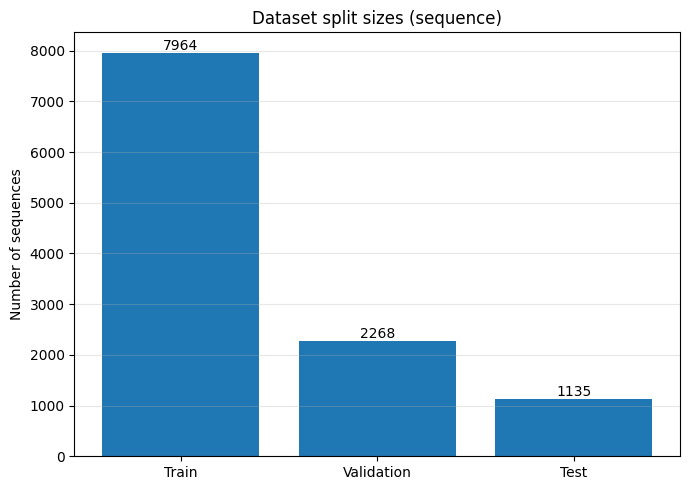

Saved figure: e:\Thesis\beam_prediction\graphs\fig_05_chronological_split_ranges.png


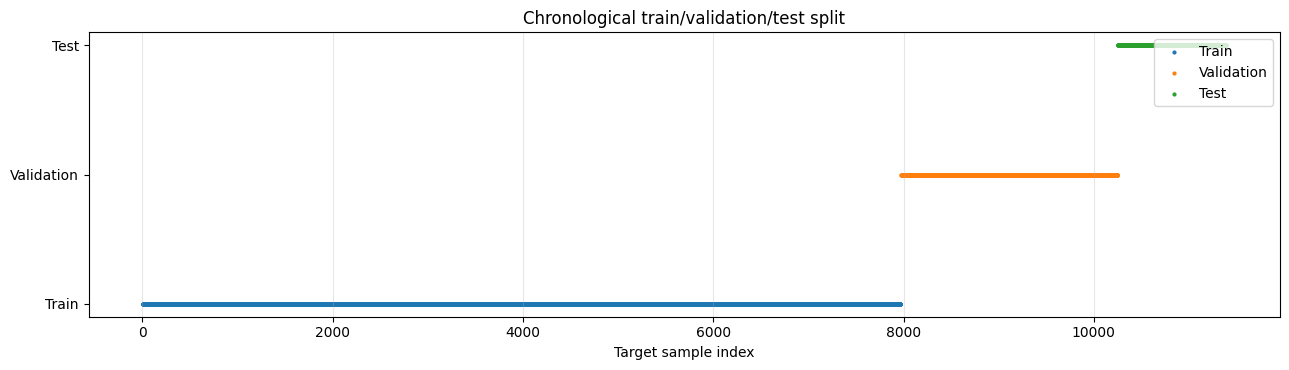

Saved figure: e:\Thesis\beam_prediction\graphs\fig_06_split_beam_distribution.png


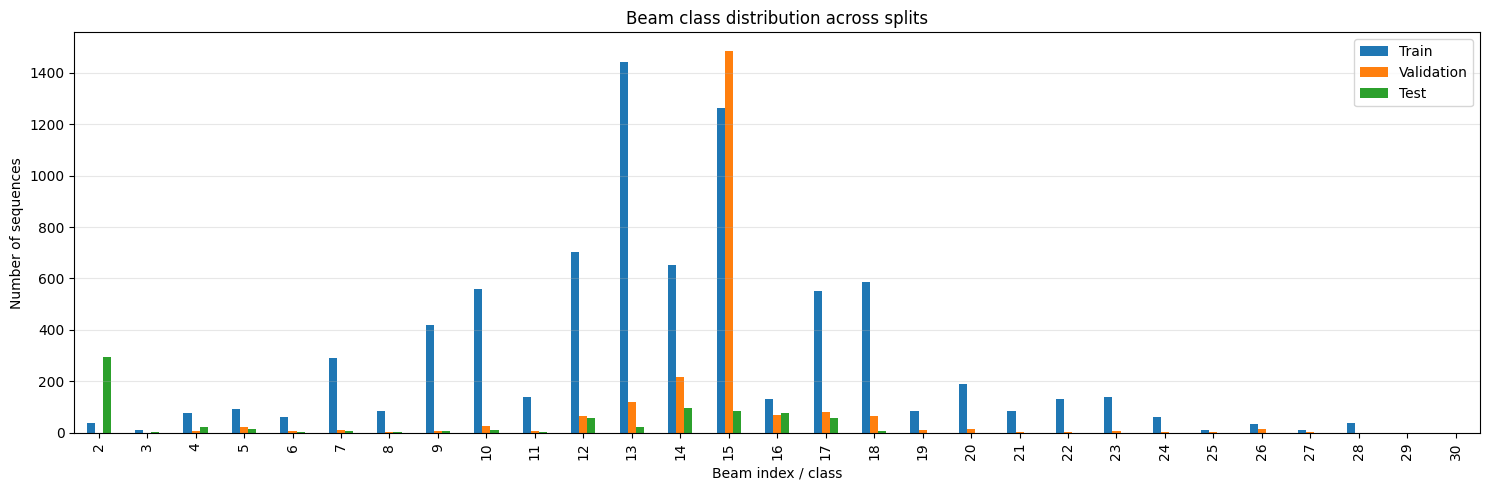

,Train,Validation,Test
2,37.0,0.0,295.0
3,12.0,0.0,5.0
4,78.0,8.0,22.0
5,94.0,22.0,17.0
6,63.0,7.0,3.0
7,292.0,10.0,9.0
8,85.0,4.0,3.0
9,418.0,9.0,8.0
10,561.0,28.0,11.0
11,141.0,9.0,4.0


In [25]:
# Figure 4: Train/validation/test sample counts
if all(name in globals() for name in ["idx_train", "idx_val", "idx_test"]):
    split_names = ["Train", "Validation", "Test"]
    split_sizes = [len(idx_train), len(idx_val), len(idx_test)]

    plt.figure(figsize=(7, 5))
    plt.bar(split_names, split_sizes)
    plt.ylabel("Number of sequences")
    plt.title(f"Dataset split sizes ({SPLIT_MODE})")
    plt.grid(axis="y", alpha=0.3)
    for i, v in enumerate(split_sizes):
        plt.text(i, v, str(v), ha="center", va="bottom")
    save_thesis_fig("fig_04_split_sample_counts.png")
    plt.show()
else:
    print("Skipped split-count figure: split indices are not available yet.")

# Figure 5: Chronological split ranges
if all(name in globals() for name in ["idx_train", "idx_val", "idx_test", "target_idx_all"]):
    plt.figure(figsize=(13, 3.8))
    plt.scatter(target_idx_all[idx_train], np.zeros(len(idx_train)), s=4, label="Train")
    plt.scatter(target_idx_all[idx_val], np.ones(len(idx_val)), s=4, label="Validation")
    plt.scatter(target_idx_all[idx_test], np.ones(len(idx_test)) * 2, s=4, label="Test")
    plt.yticks([0, 1, 2], ["Train", "Validation", "Test"])
    plt.xlabel("Target sample index")
    plt.title("Chronological train/validation/test split")
    plt.grid(axis="x", alpha=0.3)
    plt.legend(loc="upper right")
    save_thesis_fig("fig_05_chronological_split_ranges.png")
    plt.show()
else:
    print("Skipped chronological split figure: split indices or target_idx_all are not available yet.")

# Figure 6: Beam distribution per split
if all(name in globals() for name in ["y_train", "y_val", "y_test", "num_classes"]):
    class_ids = np.arange(num_classes)
    split_distribution = pd.DataFrame({
        "Train": pd.Series(y_train).value_counts().reindex(class_ids, fill_value=0),
        "Validation": pd.Series(y_val).value_counts().reindex(class_ids, fill_value=0),
        "Test": pd.Series(y_test).value_counts().reindex(class_ids, fill_value=0),
    }, index=[original_beam_label(i) for i in class_ids])

    ax = split_distribution.plot(kind="bar", figsize=(15, 5))
    ax.set_xlabel("Beam index / class")
    ax.set_ylabel("Number of sequences")
    ax.set_title("Beam class distribution across splits")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=90)
    save_thesis_fig("fig_06_split_beam_distribution.png")
    plt.show()

    display(split_distribution.head(10))
else:
    print("Skipped split beam distribution: y_train/y_val/y_test/num_classes are not available yet.")


### Split note
This notebook is now configured with `SPLIT_MODE = "random_stratified"` to improve accuracy and keep beam-class distribution balanced across train/validation/test splits.  
For a stricter leakage-safe experiment, change it back to `SPLIT_MODE = "sequence"`.

In [ ]:
train_img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.25),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.08, hue=0.02)
    ], p=0.30),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
    ], p=0.10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class PaperReplicaDataset(Dataset):
    def __init__(self, img_seq_paths, pos_seq, labels, transform=None):
        self.img_seq_paths = img_seq_paths
        self.pos_seq = torch.tensor(pos_seq, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def load_image(self, path):
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img

    def __getitem__(self, idx):
        imgs = [self.load_image(p) for p in self.img_seq_paths[idx]]
        imgs = torch.stack(imgs, dim=0)
        pos = self.pos_seq[idx]
        label = self.labels[idx]
        return imgs, pos, label

BATCH_SIZE = 8
NUM_WORKERS = 0  # Windows-safe. In Colab/Linux you may set 2 or 4.

train_dataset = PaperReplicaDataset(X_img_train, X_pos_train, y_train, transform=train_img_transform)
val_dataset = PaperReplicaDataset(X_img_val, X_pos_val, y_val, transform=eval_img_transform)
test_dataset = PaperReplicaDataset(X_img_test, X_pos_test, y_test, transform=eval_img_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

imgs_b, pos_b, y_b = next(iter(train_loader))
print("imgs_b:", imgs_b.shape)
print("pos_b:", pos_b.shape)
print("y_b:", y_b.shape)
print("label min/max:", int(y_b.min()), int(y_b.max()))


## Thesis figures: multimodal input examples

These figures show exactly what one training sample contains: four past camera frames and the corresponding position-sequence features.


In [ ]:
# Figure 7: One image sequence sample used by the model
if all(name in globals() for name in ["X_img_train", "y_train", "SEQ_LEN"]):
    sample_idx = 0
    seq_paths = X_img_train[sample_idx]
    valid_seq_paths = [p for p in seq_paths if os.path.exists(str(p))]

    if len(valid_seq_paths) > 0:
        fig, axes = plt.subplots(1, len(valid_seq_paths), figsize=(3.2 * len(valid_seq_paths), 3.4))
        if len(valid_seq_paths) == 1:
            axes = [axes]

        for t, path in enumerate(valid_seq_paths):
            img = Image.open(path).convert("RGB")
            axes[t].imshow(img)
            axes[t].set_title(f"t-{len(valid_seq_paths)-t}")
            axes[t].axis("off")

        true_beam = original_beam_label(y_train[sample_idx])
        fig.suptitle(f"Example input image sequence | target beam: {true_beam}")
        save_thesis_fig("fig_07_input_image_sequence.png")
        plt.show()
    else:
        print("Skipped image sequence figure: image files were not found.")
else:
    print("Skipped image sequence figure: X_img_train/y_train/SEQ_LEN are not available yet.")

# Figure 8: Position-sequence feature heatmap
if all(name in globals() for name in ["X_pos_train", "SEQ_LEN"]):
    sample_idx = 0
    pos_sample = X_pos_train[sample_idx]

    plt.figure(figsize=(12, 4))
    plt.imshow(pos_sample, aspect="auto")
    plt.colorbar(label="Feature value")
    plt.xlabel("Position/GPS feature dimension")
    plt.ylabel("Sequence step")
    plt.yticks(np.arange(pos_sample.shape[0]), [f"t-{pos_sample.shape[0]-i}" for i in range(pos_sample.shape[0])])
    plt.title("Example position-sequence feature map")
    save_thesis_fig("fig_08_position_sequence_heatmap.png")
    plt.show()
else:
    print("Skipped position heatmap: X_pos_train is not available yet.")

# Figure 9: Position feature variability across the training set
if "X_pos_train" in globals():
    flattened_pos = X_pos_train.reshape(-1, X_pos_train.shape[-1])
    feature_std = flattened_pos.std(axis=0)

    plt.figure(figsize=(12, 4))
    plt.plot(np.arange(len(feature_std)), feature_std, marker="o")
    plt.xlabel("Position/GPS feature dimension")
    plt.ylabel("Standard deviation")
    plt.title("Training-set position feature variability")
    plt.grid(True, alpha=0.3)
    save_thesis_fig("fig_09_position_feature_variability.png")
    plt.show()
else:
    print("Skipped position variability figure: X_pos_train is not available yet.")


## Final tuned model: ConvNeXt-Tiny + CAFormer + LSTM
This replaces the scratch SEResNet image backbone with a pretrained ConvNeXt-Tiny backbone and uses differential learning rates for fine-tuning.


In [ ]:
class CAFormerBlock(nn.Module):
    def __init__(self, embed_dim=256, num_heads=4, dropout=0.20):
        super().__init__()

        self.img_query_pos_kv = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.pos_query_img_kv = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.img_norm1 = nn.LayerNorm(embed_dim)
        self.pos_norm1 = nn.LayerNorm(embed_dim)

        self.img_ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim)
        )

        self.pos_ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim)
        )

        self.img_norm2 = nn.LayerNorm(embed_dim)
        self.pos_norm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, img_tokens, pos_tokens):
        img_cross, _ = self.img_query_pos_kv(
            query=img_tokens,
            key=pos_tokens,
            value=pos_tokens
        )

        pos_cross, _ = self.pos_query_img_kv(
            query=pos_tokens,
            key=img_tokens,
            value=img_tokens
        )

        img_tokens = self.img_norm1(img_tokens + self.dropout(img_cross))
        pos_tokens = self.pos_norm1(pos_tokens + self.dropout(pos_cross))

        img_tokens = self.img_norm2(img_tokens + self.dropout(self.img_ffn(img_tokens)))
        pos_tokens = self.pos_norm2(pos_tokens + self.dropout(self.pos_ffn(pos_tokens)))

        return img_tokens, pos_tokens

class ConvNeXtTinyEncoder(nn.Module):
    def __init__(self, output_dim=256, dropout=0.20, pretrained=True):
        super().__init__()

        self.backbone = timm.create_model(
            "convnext_tiny.fb_in22k_ft_in1k",
            pretrained=pretrained,
            num_classes=0
        )

        in_dim = self.backbone.num_features

        self.proj = nn.Sequential(
            nn.Linear(in_dim, output_dim),
            nn.LayerNorm(output_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        feat = self.backbone(x)
        return self.proj(feat)

class ConvNeXtCAFormerLSTMBeamTracker(nn.Module):
    def __init__(
        self,
        pos_input_dim,
        num_classes,
        embed_dim=256,
        num_heads=4,
        ca_layers=2,
        lstm_hidden_dim=256,
        dropout=0.20,
        pretrained=True
    ):
        super().__init__()

        self.image_encoder = ConvNeXtTinyEncoder(
            output_dim=embed_dim,
            dropout=dropout,
            pretrained=pretrained
        )

        self.position_encoder = nn.Sequential(
            nn.Linear(pos_input_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(128, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.caformer_blocks = nn.ModuleList([
            CAFormerBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                dropout=dropout
            )
            for _ in range(ca_layers)
        ])

        # Position-guided image gate: location context decides how much visual feature to use.
        self.image_gate = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.Sigmoid()
        )

        self.temporal_lstm = nn.LSTM(
            input_size=embed_dim * 2,
            hidden_size=lstm_hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=False,
            dropout=0.0
        )

        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(128, num_classes)
        )

    def forward(self, img_seq, pos_seq):
        B, T, C, H, W = img_seq.shape

        img_flat = img_seq.reshape(B * T, C, H, W)
        img_features = self.image_encoder(img_flat)
        img_tokens = img_features.reshape(B, T, -1)

        pos_tokens = self.position_encoder(pos_seq)

        for block in self.caformer_blocks:
            img_tokens, pos_tokens = block(img_tokens, pos_tokens)

        gate = self.image_gate(pos_tokens)
        img_tokens = img_tokens * gate

        fused_tokens = torch.cat([img_tokens, pos_tokens], dim=-1)
        temporal_out, _ = self.temporal_lstm(fused_tokens)

        logits = self.classifier(temporal_out[:, -1, :])
        return logits


In [ ]:
set_seed(SEED)

model = ConvNeXtCAFormerLSTMBeamTracker(
    pos_input_dim=pos_input_dim,
    num_classes=num_classes,
    embed_dim=256,
    num_heads=4,
    ca_layers=2,
    lstm_hidden_dim=256,
    dropout=0.20,
    pretrained=True
).to(device)

imgs_tmp = imgs_b.to(device)
pos_tmp = pos_b.to(device)

with torch.no_grad():
    logits_tmp = model(imgs_tmp, pos_tmp)

print("logits:", logits_tmp.shape)
print("expected:", torch.Size([imgs_tmp.size(0), num_classes]))
print("trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6, "M")


## Thesis figures: proposed model architecture

This diagram summarizes the complete multimodal beam tracking architecture used in the notebook.


In [ ]:
# Figure 10: Architecture flow diagram
def draw_architecture_box(ax, x, y, text, width=0.18, height=0.11):
    ax.text(
        x, y, text,
        ha="center", va="center", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.45", fill=False, linewidth=1.2)
    )

def draw_arrow(ax, start, end):
    ax.annotate(
        "", xy=end, xytext=start,
        arrowprops=dict(arrowstyle="->", linewidth=1.2)
    )

plt.figure(figsize=(14, 7))
ax = plt.gca()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Image branch
draw_architecture_box(ax, 0.12, 0.75, "Input image\nsequence\nT = 4")
draw_architecture_box(ax, 0.32, 0.75, "ConvNeXt-Tiny\nimage encoder")
draw_architecture_box(ax, 0.52, 0.75, "Image tokens\nB × T × 256")

# Position branch
draw_architecture_box(ax, 0.12, 0.35, "Position/GPS\nsequence\nT = 4")
draw_architecture_box(ax, 0.32, 0.35, "Position MLP\nencoder")
draw_architecture_box(ax, 0.52, 0.35, "Position tokens\nB × T × 256")

# Fusion and temporal branch
draw_architecture_box(ax, 0.70, 0.55, "CAFormer\ncross-attention\nfusion")
draw_architecture_box(ax, 0.84, 0.55, "Position-guided\nimage gate")
draw_architecture_box(ax, 0.84, 0.34, "Concatenate\nimage + position")
draw_architecture_box(ax, 0.84, 0.17, "LSTM temporal\nmodeling")
draw_architecture_box(ax, 0.84, 0.03, "Classifier:\npredicted beam")

draw_arrow(ax, (0.20, 0.75), (0.25, 0.75))
draw_arrow(ax, (0.40, 0.75), (0.45, 0.75))
draw_arrow(ax, (0.20, 0.35), (0.25, 0.35))
draw_arrow(ax, (0.40, 0.35), (0.45, 0.35))
draw_arrow(ax, (0.60, 0.75), (0.65, 0.60))
draw_arrow(ax, (0.60, 0.35), (0.65, 0.50))
draw_arrow(ax, (0.76, 0.55), (0.79, 0.55))
draw_arrow(ax, (0.84, 0.49), (0.84, 0.41))
draw_arrow(ax, (0.84, 0.28), (0.84, 0.23))
draw_arrow(ax, (0.84, 0.11), (0.84, 0.07))

plt.title("Proposed ConvNeXt-Tiny + CAFormer + LSTM Beam Tracking Architecture", fontsize=13)
save_thesis_fig("fig_10_model_architecture_flow.png")
plt.show()

# Figure 11: Trainable parameter distribution by model component
if "model" in globals():
    module_param_counts = {
        "Image encoder": sum(p.numel() for p in model.image_encoder.parameters() if p.requires_grad),
        "Position encoder": sum(p.numel() for p in model.position_encoder.parameters() if p.requires_grad),
        "CAFormer blocks": sum(p.numel() for p in model.caformer_blocks.parameters() if p.requires_grad),
        "Image gate": sum(p.numel() for p in model.image_gate.parameters() if p.requires_grad),
        "LSTM": sum(p.numel() for p in model.temporal_lstm.parameters() if p.requires_grad),
        "Classifier": sum(p.numel() for p in model.classifier.parameters() if p.requires_grad),
    }

    names = list(module_param_counts.keys())
    values_m = np.array(list(module_param_counts.values())) / 1e6

    plt.figure(figsize=(10, 5))
    plt.bar(names, values_m)
    plt.ylabel("Trainable parameters (millions)")
    plt.title("Trainable parameter distribution by component")
    plt.xticks(rotation=35, ha="right")
    plt.grid(axis="y", alpha=0.3)
    for i, v in enumerate(values_m):
        plt.text(i, v, f"{v:.2f}", ha="center", va="bottom")
    save_thesis_fig("fig_11_parameter_distribution.png")
    plt.show()
else:
    print("Skipped parameter distribution: model is not available yet.")


In [ ]:
def calculate_top1_dba_from_prediction(logits, labels, num_classes):
    pred_ids = torch.argmax(logits, dim=1)
    diff = torch.abs(pred_ids - labels)
    circular_diff = torch.minimum(diff, num_classes - diff)
    score = 1.0 - (circular_diff.float() / (num_classes / 2.0))
    score = torch.clamp(score, min=0.0, max=1.0)
    return score.mean().item()

@torch.no_grad()
def evaluate_model(model, loader, device, ks=(1, 2, 3, 5)):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    total = 0
    loss_sum = 0.0
    correct = {k: 0 for k in ks}
    dba_sum = 0.0

    for imgs, pos, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        pos = pos.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(imgs, pos)
        loss = criterion(logits, labels)

        bs = labels.size(0)
        total += bs
        loss_sum += loss.item() * bs

        max_k = max(ks)
        _, pred = torch.topk(logits, k=max_k, dim=1)

        for k in ks:
            correct[k] += pred[:, :k].eq(labels.view(-1, 1)).any(dim=1).sum().item()

        batch_dba = calculate_top1_dba_from_prediction(
            logits=logits,
            labels=labels,
            num_classes=logits.shape[1]
        )
        dba_sum += batch_dba * bs

    metrics = {"loss": loss_sum / total}
    for k in ks:
        metrics[f"top{k}"] = 100.0 * correct[k] / total
    metrics["dba"] = dba_sum / total
    return metrics

def set_backbone_trainable(model, trainable=True):
    for p in model.image_encoder.backbone.parameters():
        p.requires_grad = trainable


def train_convnext_finetuned_model(
    model,
    train_loader,
    val_loader,
    device,
    epochs=60,
    lr_backbone=1e-5,
    lr_head=1e-4,
    weight_decay=1e-4,
    label_smoothing=0.02,
    patience=15,
    freeze_backbone_epochs=3,
    save_path="best_convnext_tiny_caformer_lstm_final.pth"
):
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    backbone_params = []
    head_params = []
    for name, param in model.named_parameters():
        if "image_encoder.backbone" in name:
            backbone_params.append(param)
        else:
            head_params.append(param)

    optimizer = optim.AdamW(
        [
            {"params": backbone_params, "lr": lr_backbone},
            {"params": head_params, "lr": lr_head},
        ],
        weight_decay=weight_decay
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
        eta_min=1e-6
    )

    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    best_val_top1 = -1.0
    patience_counter = 0
    history = []

    if freeze_backbone_epochs > 0:
        set_backbone_trainable(model, False)
        print(f"Backbone frozen for first {freeze_backbone_epochs} epoch(s).")

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        if epoch == freeze_backbone_epochs + 1:
            set_backbone_trainable(model, True)
            print("Backbone unfrozen: fine-tuning ConvNeXt-Tiny.")

        model.train()
        train_total = 0
        train_loss_sum = 0.0
        train_correct = 0

        for imgs, pos, labels in train_loader:
            imgs = imgs.to(device, non_blocking=True)
            pos = pos.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                logits = model(imgs, pos)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            bs = labels.size(0)
            train_total += bs
            train_loss_sum += loss.item() * bs
            train_correct += (logits.argmax(dim=1) == labels).sum().item()

        scheduler.step()

        train_loss = train_loss_sum / train_total
        train_top1 = 100.0 * train_correct / train_total
        val_metrics = evaluate_model(model, val_loader, device, ks=(1, 2, 3, 5))
        val_top1 = val_metrics["top1"]

        epoch_time = (time.time() - start_time) / 60.0
        current_lr_backbone = optimizer.param_groups[0]["lr"]
        current_lr_head = optimizer.param_groups[1]["lr"]

        row = {
            "epoch": epoch,
            "time_min": epoch_time,
            "lr_backbone": current_lr_backbone,
            "lr_head": current_lr_head,
            "train_loss": train_loss,
            "train_top1": train_top1,
            "val_loss": val_metrics["loss"],
            "val_top1": val_metrics["top1"],
            "val_top2": val_metrics["top2"],
            "val_top3": val_metrics["top3"],
            "val_top5": val_metrics["top5"],
            "val_dba": val_metrics["dba"],
        }
        history.append(row)

        print(
            f"Epoch {epoch:03d} | Time {epoch_time:.2f} min | "
            f"LRb {current_lr_backbone:.2e} | LRh {current_lr_head:.2e} | "
            f"Train Loss {train_loss:.4f} | Train Top1 {train_top1:.2f} | "
            f"Val Loss {val_metrics['loss']:.4f} | Val Top1 {val_metrics['top1']:.2f} | "
            f"Top2 {val_metrics['top2']:.2f} | Top3 {val_metrics['top3']:.2f} | "
            f"Top5 {val_metrics['top5']:.2f} | DBA {val_metrics['dba']:.4f}"
        )

        if val_top1 > best_val_top1:
            best_val_top1 = val_top1
            patience_counter = 0
            torch.save(copy.deepcopy(model.state_dict()), save_path)
            print("Saved best model by Val Top1")
        else:
            patience_counter += 1
            print(f"Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Early stopping")
            break

    return pd.DataFrame(history)


In [ ]:
set_seed(SEED)

final_model = ConvNeXtCAFormerLSTMBeamTracker(
    pos_input_dim=pos_input_dim,
    num_classes=num_classes,
    embed_dim=256,
    num_heads=4,
    ca_layers=2,
    lstm_hidden_dim=256,
    dropout=0.20,
    pretrained=True
).to(device)

FINAL_MODEL_PATH = r"E:\Thesiseam_predictionest_convnext_tiny_caformer_lstm_final.pth"

history_final = train_convnext_finetuned_model(
    model=final_model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=60,
    lr_backbone=1e-5,
    lr_head=1e-4,
    weight_decay=1e-4,
    label_smoothing=0.02,
    patience=15,
    freeze_backbone_epochs=3,
    save_path=FINAL_MODEL_PATH
)

display(history_final.tail())


In [ ]:
final_eval_model = ConvNeXtCAFormerLSTMBeamTracker(
    pos_input_dim=pos_input_dim,
    num_classes=num_classes,
    embed_dim=256,
    num_heads=4,
    ca_layers=2,
    lstm_hidden_dim=256,
    dropout=0.20,
    pretrained=False
).to(device)

final_eval_model.load_state_dict(torch.load(FINAL_MODEL_PATH, map_location=device))
final_eval_model.eval()

test_metrics = evaluate_model(
    final_eval_model,
    test_loader,
    device,
    ks=(1, 2, 3, 5)
)

print("Final ConvNeXt-Tiny Tuned Test Metrics:")
print(f"Top-1: {test_metrics['top1']:.2f}%")
print(f"Top-2: {test_metrics['top2']:.2f}%")
print(f"Top-3: {test_metrics['top3']:.2f}%")
print(f"Top-5: {test_metrics['top5']:.2f}%")
print(f"DBA  : {test_metrics['dba']:.4f}")
print(f"Loss : {test_metrics['loss']:.4f}")


In [ ]:
# Training curves
if 'history_final' in globals() and len(history_final) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(history_final['epoch'], history_final['train_top1'], label='Train Top-1')
    plt.plot(history_final['epoch'], history_final['val_top1'], label='Val Top-1')
    plt.xlabel('Epoch')
    plt.ylabel('Top-1 Accuracy (%)')
    plt.title('ConvNeXt-Tiny CAFormer LSTM Fine-tuning')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_final['epoch'], history_final['train_loss'], label='Train Loss')
    plt.plot(history_final['epoch'], history_final['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()
    plt.grid(True)
    plt.show()


## Thesis figures: training dynamics and final evaluation diagnostics

Run these cells after the training and final test-evaluation cells. They save training curves, metric summaries, confusion matrix, beam-error plots, and qualitative prediction examples.


In [ ]:
# Figures 12-16: Training dynamics
if "history_final" in globals() and isinstance(history_final, pd.DataFrame) and len(history_final) > 0:
    hist = history_final.copy()

    plt.figure(figsize=(8, 5))
    plt.plot(hist["epoch"], hist["train_loss"], marker="o", label="Train loss")
    plt.plot(hist["epoch"], hist["val_loss"], marker="o", label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    save_thesis_fig("fig_12_training_validation_loss.png")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist["epoch"], hist["train_top1"], marker="o", label="Train Top-1")
    plt.plot(hist["epoch"], hist["val_top1"], marker="o", label="Validation Top-1")
    plt.xlabel("Epoch")
    plt.ylabel("Top-1 accuracy (%)")
    plt.title("Training and validation Top-1 accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    save_thesis_fig("fig_13_training_validation_top1.png")
    plt.show()

    topk_cols = [c for c in ["val_top1", "val_top2", "val_top3", "val_top5"] if c in hist.columns]
    if len(topk_cols) > 0:
        plt.figure(figsize=(8, 5))
        for col in topk_cols:
            plt.plot(hist["epoch"], hist[col], marker="o", label=col.replace("val_", "Validation ").upper())
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy (%)")
        plt.title("Validation Top-k accuracy curves")
        plt.legend()
        plt.grid(True, alpha=0.3)
        save_thesis_fig("fig_14_validation_topk_curves.png")
        plt.show()

    if "val_dba" in hist.columns:
        plt.figure(figsize=(8, 5))
        plt.plot(hist["epoch"], hist["val_dba"], marker="o")
        plt.xlabel("Epoch")
        plt.ylabel("DBA score")
        plt.title("Validation distance-based accuracy")
        plt.grid(True, alpha=0.3)
        save_thesis_fig("fig_15_validation_dba_curve.png")
        plt.show()

    if all(c in hist.columns for c in ["lr_backbone", "lr_head"]):
        plt.figure(figsize=(8, 5))
        plt.plot(hist["epoch"], hist["lr_backbone"], marker="o", label="Backbone LR")
        plt.plot(hist["epoch"], hist["lr_head"], marker="o", label="Head LR")
        plt.xlabel("Epoch")
        plt.ylabel("Learning rate")
        plt.title("Differential learning-rate schedule")
        plt.yscale("log")
        plt.legend()
        plt.grid(True, alpha=0.3)
        save_thesis_fig("fig_16_learning_rate_schedule.png")
        plt.show()
else:
    print("Skipped training-dynamics figures: history_final is not available yet.")


In [ ]:
# Figures 17-22: Test-set diagnostic plots and qualitative examples
@torch.no_grad()
def collect_prediction_records(model_for_eval, loader, device, max_topk=5):
    model_for_eval.eval()
    rows = []
    running_index = 0

    for imgs, pos, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        pos = pos.to(device, non_blocking=True)
        labels_device = labels.to(device, non_blocking=True)

        logits = model_for_eval(imgs, pos)
        probs = torch.softmax(logits, dim=1)
        top_probs, top_indices = torch.topk(probs, k=min(max_topk, probs.shape[1]), dim=1)

        for i in range(labels.size(0)):
            true_id = int(labels[i].item())
            pred_id = int(top_indices[i, 0].item())
            diff = abs(pred_id - true_id)
            circular_diff = min(diff, int(probs.shape[1]) - diff)

            row = {
                "sample_index": running_index + i,
                "true_class_id": true_id,
                "pred_class_id": pred_id,
                "true_beam": original_beam_label(true_id),
                "pred_beam": original_beam_label(pred_id),
                "top1_confidence": float(top_probs[i, 0].item()),
                "absolute_class_error": diff,
                "circular_class_error": circular_diff,
                "is_correct": bool(pred_id == true_id),
            }

            for k in range(top_indices.shape[1]):
                row[f"top{k+1}_class_id"] = int(top_indices[i, k].item())
                row[f"top{k+1}_beam"] = original_beam_label(int(top_indices[i, k].item()))
                row[f"top{k+1}_prob"] = float(top_probs[i, k].item())

            rows.append(row)

        running_index += labels.size(0)

    return pd.DataFrame(rows)

if all(name in globals() for name in ["test_loader", "device"]):
    if "final_eval_model" in globals():
        model_for_figures = final_eval_model
    elif "final_model" in globals():
        model_for_figures = final_model
    else:
        model_for_figures = None

    if model_for_figures is not None:
        test_prediction_records = collect_prediction_records(model_for_figures, test_loader, device, max_topk=5)
        csv_path = THESIS_GRAPH_DIR / "test_prediction_records.csv"
        test_prediction_records.to_csv(csv_path, index=False)
        print("Saved prediction records:", csv_path)
        display(test_prediction_records.head())

        # Figure 17: Final Top-k performance bar chart
        topk_scores = {}
        for k in [1, 2, 3, 5]:
            if f"top{k}_class_id" in test_prediction_records.columns:
                topk_scores[f"Top-{k}"] = 100.0 * np.mean([
                    row["true_class_id"] in [row.get(f"top{i}_class_id", -1) for i in range(1, k + 1)]
                    for _, row in test_prediction_records.iterrows()
                ])

        if len(topk_scores) > 0:
            plt.figure(figsize=(7, 5))
            plt.bar(list(topk_scores.keys()), list(topk_scores.values()))
            plt.ylabel("Accuracy (%)")
            plt.title("Final test Top-k accuracy")
            plt.ylim(0, max(100, max(topk_scores.values()) + 5))
            plt.grid(axis="y", alpha=0.3)
            for i, v in enumerate(topk_scores.values()):
                plt.text(i, v, f"{v:.2f}%", ha="center", va="bottom")
            save_thesis_fig("fig_17_final_test_topk_accuracy.png")
            plt.show()

        # Figure 18: Normalized confusion matrix
        class_ids = np.arange(num_classes)
        cm = confusion_matrix(
            test_prediction_records["true_class_id"],
            test_prediction_records["pred_class_id"],
            labels=class_ids
        )
        cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

        plt.figure(figsize=(10, 8))
        plt.imshow(cm_norm, aspect="auto")
        plt.colorbar(label="Normalized count")
        plt.xlabel("Predicted beam class")
        plt.ylabel("True beam class")
        plt.title("Normalized confusion matrix on test set")
        tick_labels = [str(original_beam_label(i)) for i in class_ids]
        plt.xticks(class_ids, tick_labels, rotation=90, fontsize=7)
        plt.yticks(class_ids, tick_labels, fontsize=7)
        save_thesis_fig("fig_18_normalized_confusion_matrix.png")
        plt.show()

        # Figure 19: Per-class test accuracy
        per_class_accuracy = np.diag(cm) / np.maximum(cm.sum(axis=1), 1)
        plt.figure(figsize=(13, 5))
        plt.bar(class_ids, per_class_accuracy * 100)
        plt.xticks(class_ids, tick_labels, rotation=90)
        plt.xlabel("Beam index / class")
        plt.ylabel("Accuracy (%)")
        plt.title("Per-class Top-1 accuracy on test set")
        plt.grid(axis="y", alpha=0.3)
        save_thesis_fig("fig_19_per_class_test_accuracy.png")
        plt.show()

        # Figure 20: Circular beam-class error histogram
        max_error = int(test_prediction_records["circular_class_error"].max())
        bins = np.arange(-0.5, max_error + 1.5, 1)
        plt.figure(figsize=(8, 5))
        plt.hist(test_prediction_records["circular_class_error"], bins=bins)
        plt.xlabel("Circular beam-class error")
        plt.ylabel("Number of test samples")
        plt.title("Beam prediction error distribution")
        plt.grid(axis="y", alpha=0.3)
        save_thesis_fig("fig_20_circular_beam_error_histogram.png")
        plt.show()

        # Figure 21: Confidence distribution for correct and incorrect predictions
        plt.figure(figsize=(7, 5))
        correct_conf = test_prediction_records.loc[test_prediction_records["is_correct"], "top1_confidence"]
        wrong_conf = test_prediction_records.loc[~test_prediction_records["is_correct"], "top1_confidence"]
        plt.boxplot([correct_conf, wrong_conf], labels=["Correct", "Incorrect"])
        plt.ylabel("Top-1 softmax confidence")
        plt.title("Prediction confidence by correctness")
        plt.grid(axis="y", alpha=0.3)
        save_thesis_fig("fig_21_confidence_correct_vs_incorrect.png")
        plt.show()

        # Figure 22: Qualitative prediction examples
        if "X_img_test" in globals() and len(test_prediction_records) > 0:
            correct_examples = test_prediction_records[test_prediction_records["is_correct"]].head(2)
            wrong_examples = test_prediction_records[~test_prediction_records["is_correct"]].head(2)
            example_df = pd.concat([correct_examples, wrong_examples], axis=0).head(4)

            if len(example_df) > 0:
                n_rows = len(example_df)
                n_cols = len(X_img_test[int(example_df.iloc[0]["sample_index"])])
                fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.0 * n_cols, 3.0 * n_rows))
                if n_rows == 1:
                    axes = np.expand_dims(axes, axis=0)
                if n_cols == 1:
                    axes = np.expand_dims(axes, axis=1)

                for row_i, (_, rec) in enumerate(example_df.iterrows()):
                    seq_paths = X_img_test[int(rec["sample_index"])]
                    for col_i, path in enumerate(seq_paths):
                        ax = axes[row_i, col_i]
                        if os.path.exists(str(path)):
                            ax.imshow(Image.open(path).convert("RGB"))
                        ax.axis("off")
                        if row_i == 0:
                            ax.set_title(f"t-{len(seq_paths)-col_i}")

                    axes[row_i, 0].set_ylabel(
                        f"True: {rec['true_beam']}\nPred: {rec['pred_beam']}\nConf: {rec['top1_confidence']:.2f}",
                        rotation=0,
                        ha="right",
                        va="center",
                        labelpad=60
                    )

                fig.suptitle("Qualitative test prediction examples")
                save_thesis_fig("fig_22_qualitative_prediction_examples.png")
                plt.show()
            else:
                print("Skipped qualitative examples: no prediction examples available.")
        else:
            print("Skipped qualitative examples: X_img_test is not available.")
    else:
        print("Skipped evaluation diagnostics: no trained/evaluation model was found.")
else:
    print("Skipped evaluation diagnostics: test_loader/device are not available yet.")


## Final model summary

**Architecture:** Pretrained ConvNeXt-Tiny image encoder + position MLP + CAFormer cross-attention fusion + temporal LSTM + beam classifier.  
**Fine-tuning:** differential LR (`1e-5` backbone, `1e-4` head), AMP mixed precision, label smoothing `0.02`, AdamW, cosine LR, gradient clipping, early stopping, and best checkpoint saved by validation Top-1.  
**Current split:** `SPLIT_MODE = "random_stratified"` for higher-accuracy comparison. For stricter paper-style leakage-safe evaluation, switch to `SPLIT_MODE = "sequence"`.